<a href="https://colab.research.google.com/github/Ammarah171/NLP/blob/main/%5BSummer25%5DCSE440_Lab_3_Introduction_to_Pandas_and_Keras_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dataset Load From Google Drive Public Link

In [ ]:
import pandas as pd

In [ ]:
# read dataset from a Google Drive File
file_link = 'https://drive.google.com/file/d/1bTAgEjug-zC5Iso4GJe8xoMzWp1AEwxH/view?usp=sharing' # the file access must have to be Public
id = file_link.split("/")[-2]
print(id)
new_link = f'https://drive.google.com/uc?id={id}'
print(new_link)
df = pd.read_csv(new_link)

1bTAgEjug-zC5Iso4GJe8xoMzWp1AEwxH
https://drive.google.com/uc?id=1bTAgEjug-zC5Iso4GJe8xoMzWp1AEwxH


In [ ]:
df.head()

,ID,Clump,UnifSize,UnifShape,MargAdh,SingEpiSize,BareNuc,BlandChrom,NormNucl,Mit,Class
0,1000025,5,1,1,1,2,1,3,1,1,0
1,1002945,5,4,4,5,7,10,3,2,1,0
2,1015425,3,1,1,1,2,2,3,1,1,0
3,1016277,6,8,8,1,3,4,3,7,1,0
4,1017023,4,1,1,3,2,1,3,1,1,0


In [ ]:
df.describe()

,ID,Clump,UnifSize,UnifShape,MargAdh,SingEpiSize,BareNuc,BlandChrom,NormNucl,Mit,Class
count,6.990000e+02,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000
mean,1.071704e+06,4.417740,3.134478,3.207439,2.806867,3.216023,3.486409,3.437768,2.866953,1.589413,0.344778
std,6.170957e+05,2.815741,3.051459,2.971913,2.855379,2.214300,3.621929,2.438364,3.053634,1.715078,0.475636
min,6.163400e+04,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
25%,8.706885e+05,2.000000,1.000000,1.000000,1.000000,2.000000,1.000000,2.000000,1.000000,1.000000,0.000000
50%,1.171710e+06,4.000000,1.000000,1.000000,1.000000,2.000000,1.000000,3.000000,1.000000,1.000000,0.000000
75%,1.238298e+06,6.000000,5.000000,5.000000,4.000000,4.000000,5.000000,5.000000,4.000000,1.000000,1.000000
max,1.345435e+07,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,1.000000


In [ ]:
df.dtypes

,0
ID,int64
Clump,int64
UnifSize,int64
UnifShape,int64
MargAdh,int64
SingEpiSize,int64
BareNuc,int64
BlandChrom,int64
NormNucl,int64
Mit,int64


# Machine Learning

## Preprocessing


### Data splitting


In [ ]:
X = df.drop(['ID', 'Class'], axis=1)
y = df['Class']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Feature scaling

In [ ]:
X_train.head(1)

,Clump,UnifSize,UnifShape,MargAdh,SingEpiSize,BareNuc,BlandChrom,NormNucl,Mit
82,5,2,1,1,2,1,3,1,1


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [ ]:
X_train[0]

array([ 0.16488604, -0.38317451, -0.76069772, -0.64250678, -0.55496377,
       -0.69889302, -0.18320521, -0.60149186, -0.34972397])

## Model training (Logistic Regression)

In [ ]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

Evaluation

In [ ]:
from sklearn.metrics import accuracy_score, f1_score
lr_pred = lr_model.predict(X_test)
lr_accuracy = accuracy_score(y_test, lr_pred)
lr_f1 = f1_score(y_test, lr_pred)
print("LR Accuracy:", lr_accuracy)
print("LR F1 Score:", lr_f1)

LR Accuracy: 0.9642857142857143
LR F1 Score: 0.9425287356321839


## Model training (Naive Bayes)


In [ ]:
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

GaussianNB()

In [ ]:
nb_pred = nb_model.predict(X_test)
nb_accuracy = accuracy_score(y_test, nb_pred)
nb_f1 = f1_score(y_test, nb_pred)
print("NB Accuracy:", nb_accuracy)
print("NB F1 Score:", nb_f1)

NB Accuracy: 0.9642857142857143
NB F1 Score: 0.946236559139785


## Model training (Random Forest)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)

RandomForestClassifier()

In [ ]:
rf_pred = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)
print("RF Accuracy:", rf_accuracy)
print("RF F1 Score:", rf_f1)


RF Accuracy: 0.9642857142857143
RF F1 Score: 0.9438202247191011


Classification Score

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.97      0.98      0.97        95
           1       0.95      0.93      0.94        45

    accuracy                           0.96       140
   macro avg       0.96      0.96      0.96       140
weighted avg       0.96      0.96      0.96       140



# What about textual data?

Load the spam ham dataset

In [ ]:

# read dataset from a Google Drive File
file_link = 'https://drive.google.com/file/d/1hWX7aB-Cx4OeOsjHTE-Iq1SfxFUpf71t/view?usp=sharing' # the file access must have to be Public
id = file_link.split("/")[-2]
print(id)
new_link = f'https://drive.google.com/uc?id={id}'
print(new_link)
df = pd.read_csv(new_link)

1hWX7aB-Cx4OeOsjHTE-Iq1SfxFUpf71t
https://drive.google.com/uc?id=1hWX7aB-Cx4OeOsjHTE-Iq1SfxFUpf71t


In [ ]:
df.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
# Split the dataset into 80:20
X_train, X_test, y_train, y_test = train_test_split(df['Message'], df['Category'], test_size=0.2, random_state=42)

In [ ]:
# Preprocessing: convert to small letter
X_train = X_train.str.lower()
X_test = X_test.str.lower()

# Label encoding: ham=0, spam=1
y_train = y_train.map({'ham': 0, 'spam': 1})
y_test = y_test.map({'ham': 0, 'spam': 1})



We need to convert text to vector representation. Lets use TF-IDF. You can use others like Bag of word, Skipgram, cbow, glove or other too!

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# TF-IDF Vectorization
tfidf_vectorizer = TfidfVectorizer()
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)


Using Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
# Model Training (Logistic Regression)
lr_model = LogisticRegression()
lr_model.fit(X_train_tfidf, y_train)


LogisticRegression()

In [ ]:
from sklearn.metrics import classification_report
# Model Evaluation
y_pred = lr_model.predict(X_test_tfidf)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      1.00      0.99       966
           1       1.00      0.81      0.90       149

    accuracy                           0.97      1115
   macro avg       0.99      0.91      0.94      1115
weighted avg       0.98      0.97      0.97      1115



A prediction function for using the model

In [ ]:
def predict_spam(sentence):
  # Preprocess the input sentence (convert to lowercase)
  sentence_lower = sentence.lower()
  # Transform the sentence using the fitted TF-IDF vectorizer
  sentence_tfidf = tfidf_vectorizer.transform([sentence_lower])
  # Predict using the trained Logistic Regression model
  prediction = lr_model.predict(sentence_tfidf)
  # Return 'spam' or 'ham' based on the prediction
  if prediction[0] == 1:
    return 'spam'
  else:
    return 'ham'

# Example usage:
test_sentence1 = "Congratulations! You've won a free prize!"
prediction1 = predict_spam(test_sentence1)
print(f"'{test_sentence1}' is predicted as: {prediction1}")

test_sentence2 = "Hey, how are you doing today?"
prediction2 = predict_spam(test_sentence2)
print(f"'{test_sentence2}' is predicted as: {prediction2}")

'Congratulations! You've won a free prize!' is predicted as: spam
'Hey, how are you doing today?' is predicted as: ham


# Neural Network Using Keras


## Tabular Data, Regression Task Example



In [ ]:
import numpy as np
import tensorflow as tf
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [ ]:
# Load data
data = fetch_california_housing()
X, y = data.data, data.target

In [ ]:
#Spliting
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
#Scale features (important for NN)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

In [ ]:
X_train_s.shape[1]

8

In [ ]:
# Buiilding the model
model = Sequential([
    Dense(10, activation="relu", input_shape=(X_train_s.shape[1],)),
    Dense(1)  # linear output for regression
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(optimizer="SGD", loss="mse", metrics=[tf.keras.metrics.MeanSquaredError()])


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │            90 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101 (404.00 B)

 Trainable params: 101 (404.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.fit(
    X_train_s, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
)

Epoch 1/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 3.5358 - mean_squared_error: 3.5358 - val_loss: 0.6538 - val_mean_squared_error: 0.6538
Epoch 2/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6094 - mean_squared_error: 0.6094 - val_loss: 0.5792 - val_mean_squared_error: 0.5792
Epoch 3/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5347 - mean_squared_error: 0.5347 - val_loss: 0.5329 - val_mean_squared_error: 0.5329
Epoch 4/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.5022 - mean_squared_error: 0.5022 - val_loss: 0.5037 - val_mean_squared_error: 0.5037
Epoch 5/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4739 - mean_squared_error: 0.4739 - val_loss: 0.4901 - val_mean_squared_error: 0.4901
Epoch 6/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.4632 - mean_squared_error: 0.4632 - val_loss: 0.4830 - val_mean_squared_error: 0.4830
Epoch 7/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4529 - mean_squared_error: 0.4529 - val_loss: 0.47

In [ ]:
test_loss, test_rmse = model.evaluate(X_test_s, y_test, verbose=0)
y_pred = model.predict(X_test_s, verbose=0).ravel()
print("Test MSE:", test_loss)
print("Test RMSE (Keras metric):", test_rmse)

Test MSE: 0.4481857120990753
Test RMSE (Keras metric): 0.4481857120990753


In [ ]:
model.save("my_model.keras")

In [ ]:
from tensorflow.keras.models import load_model

loaded_model = load_model("my_model.keras")

test_loss, test_rmse = loaded_model.evaluate(X_test_s, y_test, verbose=0)
print("Test MSE:", test_loss)
print("Test RMSE (Keras metric):", test_rmse)

Test MSE: 0.4481857120990753
Test RMSE (Keras metric): 0.4481857120990753


## Tabular Data, Classification Task Example


In [ ]:
# 1) Load data
from sklearn.datasets import load_iris
iris = load_iris()
X, y = iris.data, iris.target

In [ ]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [ ]:
# One-hot encode labels for categorical_crossentropy
from tensorflow.keras.utils import to_categorical
y_oh = to_categorical(y, num_classes=3)
y_oh

array([[1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0

In [ ]:
# 2) Train/test split (80/20), stratify keeps the same class distribution in both sets as in the original dataset.
X_train, X_test, y_train, y_test = train_test_split(
    X, y_oh, test_size=0.2, stratify=y
)

In [ ]:
# 3) Scale features
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

In [ ]:
X_train_s.shape[1]

4

In [ ]:
# 4) Build model (1 hidden layer: 16 ReLU; output: 3 softmax)
model = Sequential([
    Dense(16, activation="relu", input_shape=(X_train_s.shape[1],)),
    Dense(3, activation="softmax")
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# 5) Compile (Adam, categorical cross-entropy)
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 131 (524.00 B)

 Trainable params: 131 (524.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train_s, y_train,
    epochs=10,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

Epoch 1/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.5999 - loss: 1.0853 - val_accuracy: 0.6250 - val_loss: 1.0589
Epoch 2/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6214 - loss: 1.0614 - val_accuracy: 0.6250 - val_loss: 1.0269
Epoch 3/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5763 - loss: 1.0652 - val_accuracy: 0.6667 - val_loss: 0.9958
Epoch 4/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5854 - loss: 1.0465 - val_accuracy: 0.6667 - val_loss: 0.9656
Epoch 5/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5850 - loss: 1.0124 - val_accuracy: 0.6667 - val_loss: 0.9370
Epoch 6/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6086 - loss: 0.9551 - val_accuracy: 0.6667 - val_loss: 0.9090
Epoch 7/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6829 - loss: 0.8743 - val_accuracy: 0.6667 - val_loss: 0.8821
Epoch 8/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6246 - loss: 0.8823 - val_accuracy: 0.6667 - val_loss: 0.8560


Plotting Different Curves (Accuracy, Loss)

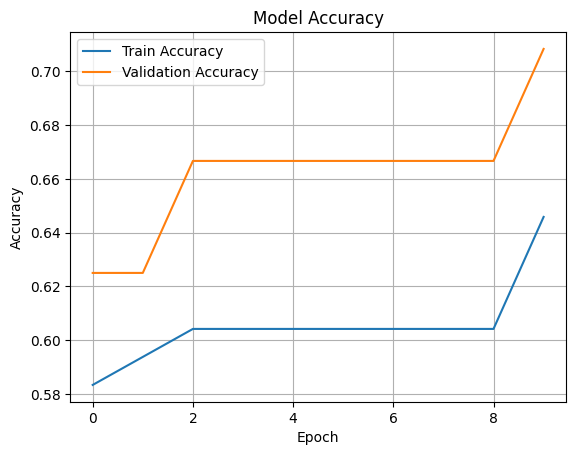

In [ ]:
from matplotlib import pyplot as plt
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

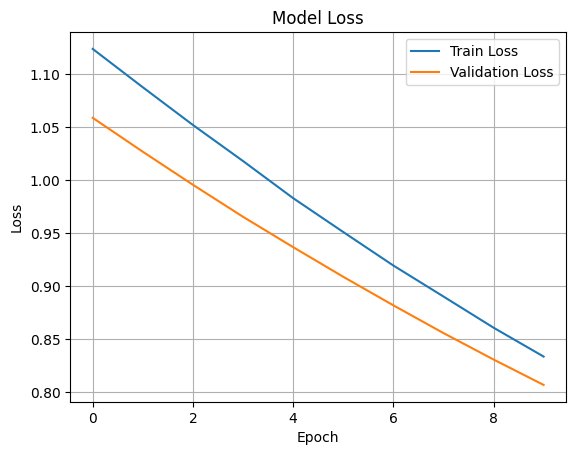

In [ ]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

In [ ]:
# 7) Evaluate on test set
test_loss, test_acc = model.evaluate(X_test_s, y_test, verbose=0)
print(f"Test Loss: {test_loss:.4f}  |  Test Accuracy: {test_acc:.4f}")

Test Loss: 0.8478  |  Test Accuracy: 0.6333


In [ ]:
# Predict class probabilities for test set
y_pred_probs = model.predict(X_test_s, verbose=0)

# Convert one-hot encoded labels and predictions back to class indices
y_true = np.argmax(y_test, axis=1)
y_pred = np.argmax(y_pred_probs, axis=1)

# Print classification report
print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=iris.target_names))

Classification Report:

              precision    recall  f1-score   support

      setosa       0.91      1.00      0.95        10
  versicolor       0.50      0.90      0.64        10
   virginica       0.00      0.00      0.00        10

    accuracy                           0.63        30
   macro avg       0.47      0.63      0.53        30
weighted avg       0.47      0.63      0.53        30



#Textual Data Classification using NN

In [ ]:

# read dataset from a Google Drive File
file_link = 'https://drive.google.com/file/d/1hWX7aB-Cx4OeOsjHTE-Iq1SfxFUpf71t/view?usp=sharing' # the file access must have to be Public
id = file_link.split("/")[-2]
print(id)
new_link = f'https://drive.google.com/uc?id={id}'
print(new_link)
df = pd.read_csv(new_link)

1hWX7aB-Cx4OeOsjHTE-Iq1SfxFUpf71t
https://drive.google.com/uc?id=1hWX7aB-Cx4OeOsjHTE-Iq1SfxFUpf71t


In [ ]:
df.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
# 1) Prepare labels & splits

le = LabelEncoder()
y = le.fit_transform(df["Category"])  # spam=1, ham=0
X_text = df["Message"].astype(str).values

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
vec = TfidfVectorizer(max_features=10000, ngram_range=(1,2), stop_words="english")
X_train = vec.fit_transform(X_train_text)
X_test  = vec.transform(X_test_text)
print(type(X_train))
# Keras Dense expects dense arrays; convert
X_train = X_train.astype("float32").toarray()
X_test  = X_test.astype("float32").toarray()
print(type(X_train))

<class 'scipy.sparse._csr.csr_matrix'>
<class 'numpy.ndarray'>


In [ ]:
X_train.shape

(4457, 10000)

In [ ]:
from tensorflow.keras.layers import Dense, Dropout

model = Sequential([
    Dense(32, activation="relu", input_shape=(X_train.shape[1],)),
    Dense(16, activation="relu"),
    Dropout(0.2),
    Dense(8, activation="relu"),
    Dense(1, activation="sigmoid")
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_26 (Dense)                │ (None, 32)             │       320,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 320,705 (1.22 MB)

 Trainable params: 320,705 (1.22 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
es = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    callbacks=[es],
    verbose=1
)

Epoch 1/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.8541 - loss: 0.6505 - val_accuracy: 0.8430 - val_loss: 0.4648
Epoch 2/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8769 - loss: 0.3474 - val_accuracy: 0.9025 - val_loss: 0.2305
Epoch 3/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9701 - loss: 0.1349 - val_accuracy: 0.9652 - val_loss: 0.1234
Epoch 4/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9932 - loss: 0.0541 - val_accuracy: 0.9765 - val_loss: 0.0913
Epoch 5/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9973 - loss: 0.0223 - val_accuracy: 0.9776 - val_loss: 0.0879
Epoch 6/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9976 - loss: 0.0116 - val_accuracy: 0.9753 - val_loss: 0.0981
Epoch 7/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9997 - loss: 0.0053 - val_accuracy: 0.9731 - val_loss: 0.1120
Epoch 8/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.9992 - loss: 0.0058 - val_accuracy: 0.9776 - v

In [ ]:
# 5) Evaluate

loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {loss:.4f} | Test Accuracy: {acc:.4f}")

y_prob = model.predict(X_test, verbose=0).ravel()
y_pred = (y_prob >= 0.5).astype(int)

print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=le.classes_))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Accuracy (sklearn):", accuracy_score(y_test, y_pred))

Test Loss: 0.0715 | Test Accuracy: 0.9758

Classification Report:
               precision    recall  f1-score   support

         ham       0.98      0.99      0.99       966
        spam       0.94      0.87      0.91       149

    accuracy                           0.98      1115
   macro avg       0.96      0.93      0.95      1115
weighted avg       0.98      0.98      0.98      1115

Confusion Matrix:
 [[958   8]
 [ 19 130]]
Accuracy (sklearn): 0.9757847533632287


Plotting Different Curves (Accuracy, Loss)

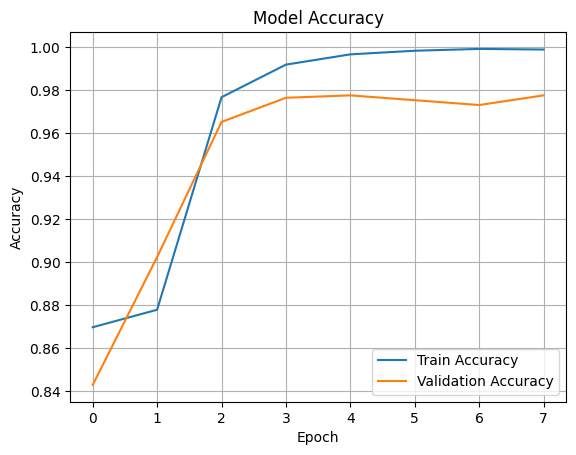

In [ ]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

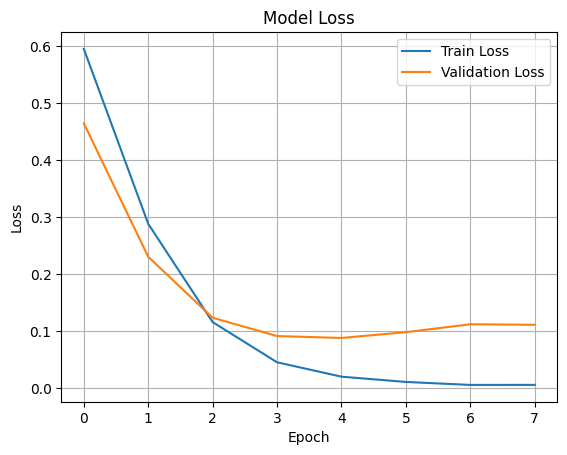

In [ ]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)